# Retention Cohort Analysis — TaxFlow (sample SaaS)

**Author:** Asif Ishtiaque

---

## 1. The business problem

TaxFlow (fictional B2B SaaS for tax professionals, $79/mo) is growing signups but
revenue is flat. Leadership suspects a leaky bucket: we acquire users but don't keep them.

**Business question:** *Are we retaining the users we acquire — and where exactly is retention leaking?*

**Hypotheses (written before looking at the data):**
1. Retention differs sharply by acquisition channel — some paid spend may be buying churn.
2. A recent product change degraded early retention for one or more cohorts.
3. Users who do a specific high-value action in week 1 retain much better (an activation lever).

## 2. Definitions — decided up front, before any results

| Decision | Choice | Why |
|---|---|---|
| Cohort event | **Signup month** | Stable, unambiguous entry point |
| Retention event | Any **value event** (`case_opened`, `client_message_sent`, `document_uploaded`, `quote_generated`) | Logins ≠ value. We count actions that deliver the product's core value |
| Window type | **Rolling 30-day windows** since each user's signup (M0 = days 0–29, M1 = days 30–59, …) | Avoids calendar-spillover distortion (a Jan-30 signup's first week would otherwise land in "month 1") |
| Maturity rule | A cell only counts if **every** user in the cohort could have completed that window by the pull date | Prevents the classic mistake of reading half-finished windows as churn |


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os

os.listdir('/content/drive/MyDrive/Colab Notebooks/Datasets')

['raw_events.csv']

In [34]:
pip install plotly


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PULL_DATE = pd.Timestamp("2025-09-30")
VALUE_EVENTS = {"case_opened", "client_message_sent", "document_uploaded", "quote_generated"}

raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/raw_events.csv", parse_dates=["event_date", "signup_date"])
print(f"Raw: {len(raw):,} rows, {raw['user_id'].nunique():,} distinct user_ids")
raw.head()

Raw: 43,693 rows, 6,180 distinct user_ids


,user_id,event_date,event_name,channel,signup_date
0,u_04053,2025-04-17,quote_generated,organic,2025-02-15
1,u_03440,2025-09-06,quote_generated,organic,2025-05-03
2,u_00340,2025-04-15,quote_generated,organic,2025-03-22
3,u_01425,2025-05-24,case_opened,content,2025-05-07
4,u_01887,2025-04-12,client_message_sent,content,2025-04-04


## 3. Cleaning — log every exclusion

Rigor lives here. Each filter is recorded with a row count so anyone can audit
(and challenge) the exclusions. Typical real-world removals: internal/test accounts,
duplicates from pipeline retries, and instrumentation bugs (events before signup,
future-dated events).

In [20]:
log = []
df = raw.copy()

n = len(df); df = df.dropna(subset=["user_id"])
log.append(("Null user_id", n - len(df)))

n = len(df); df = df[~df["user_id"].astype(str).str.startswith("test_")]
log.append(("Test/internal accounts", n - len(df)))

n = len(df); df = df.drop_duplicates()
log.append(("Exact duplicate rows", n - len(df)))

n = len(df); df = df[df["event_date"] >= df["signup_date"]]
log.append(("Events before signup (instrumentation bug)", n - len(df)))

n = len(df); df = df[df["event_date"] <= PULL_DATE]
log.append(("Future-dated events", n - len(df)))

cleaning_log = pd.DataFrame(log, columns=["exclusion", "rows_removed"])
cleaning_log["pct_of_raw"] = (cleaning_log["rows_removed"] / len(raw) * 100).round(2)
print(f"Clean: {len(df):,} rows, {df['user_id'].nunique():,} users")
cleaning_log

Clean: 40,366 rows, 6,000 users


,exclusion,rows_removed,pct_of_raw
0,Null user_id,131,0.30
1,Test/internal accounts,1594,3.65
2,Exact duplicate rows,1309,3.00
3,Events before signup (instrumentation bug),208,0.48
4,Future-dated events,85,0.19


## 4. Build the cohort matrix

Logic in plain words:
1. Tag each event with the user's **signup month** (the cohort).
2. Compute the **30-day window offset**: `(event_date − signup_date) // 30`.
3. Count **distinct active users** per (cohort, offset) cell.
4. **Mask immature cells**, then divide by cohort size to get percentages.

In [21]:
value_df = df[df["event_name"].isin(VALUE_EVENTS)].copy()
value_df["cohort_month"] = value_df["signup_date"].dt.to_period("M")
value_df["month_offset"] = (value_df["event_date"] - value_df["signup_date"]).dt.days // 30

def mask_immature(counts):
    """NaN-out windows that not every user in the cohort has lived through."""
    out = counts.astype(float)
    for cohort in out.index:
        last_signup = cohort.to_timestamp(how="end")  # conservative: latest possible signup
        for offset in out.columns:
            if last_signup + pd.Timedelta(days=30 * (offset + 1)) > PULL_DATE:
                out.loc[cohort, offset] = np.nan
    return out

counts = (value_df.groupby(["cohort_month", "month_offset"])["user_id"]
          .nunique().unstack(fill_value=0))
counts = mask_immature(counts)

cohort_sizes = value_df.groupby("cohort_month")["user_id"].nunique().rename("cohort_size")
retention = counts.div(cohort_sizes, axis=0)
(retention * 100).round(1)

month_offset,0,1,2,3,4,5,6,7,8
cohort_month,,,,,,,,,
2025-01,100.0,46.5,30.7,22.2,16.1,11.4,9.2,7.9,NaN
2025-02,100.0,44.2,32.4,23.4,18.6,14.4,11.0,NaN,NaN
2025-03,100.0,29.3,21.0,16.5,11.9,8.8,NaN,NaN,NaN
2025-04,100.0,42.2,31.0,23.3,17.0,NaN,NaN,NaN,NaN
2025-05,100.0,47.5,34.0,22.5,NaN,NaN,NaN,NaN,NaN
2025-06,100.0,40.8,29.7,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Heatmap — how to read it

- **Across a row** → the retention curve. Flattening = a retained core (good). Decay to zero = leaky product.
- **Down a column** → are newer cohorts better at the same age? This measures whether product changes work.
- **Look for anomalies** → a single cohort that breaks the pattern points to a specific change in that period.

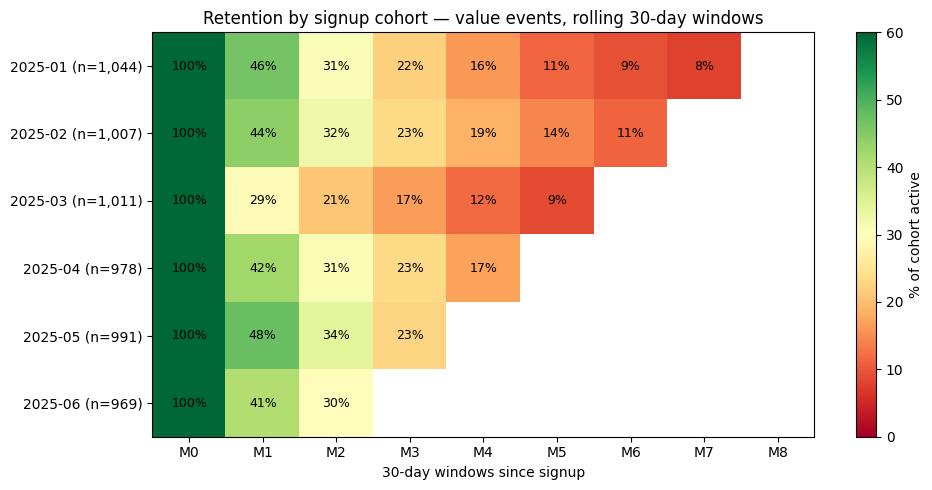

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
data = retention.values * 100
im = ax.imshow(data, cmap="RdYlGn", vmin=0, vmax=60, aspect="auto")
ax.set_xticks(range(len(retention.columns)))
ax.set_xticklabels([f"M{c}" for c in retention.columns])
ax.set_yticks(range(len(retention.index)))
ax.set_yticklabels([f"{idx} (n={int(cohort_sizes[idx]):,})" for idx in retention.index])
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if not np.isnan(data[i, j]):
            ax.text(j, i, f"{data[i, j]:.0f}%", ha="center", va="center", fontsize=9)
ax.set_title("Retention by signup cohort — value events, rolling 30-day windows")
ax.set_xlabel("30-day windows since signup")
fig.colorbar(im, label="% of cohort active")
plt.tight_layout(); plt.show()

**Reading:** the March 2025 cohort is the anomaly — M1 of ~29% vs ~42–48% for every
other cohort, and the deficit persists at every later age. Something that affected
new users specifically changed in March (in this simulation: an onboarding regression).
This is exactly the kind of finding a column-wise read surfaces.

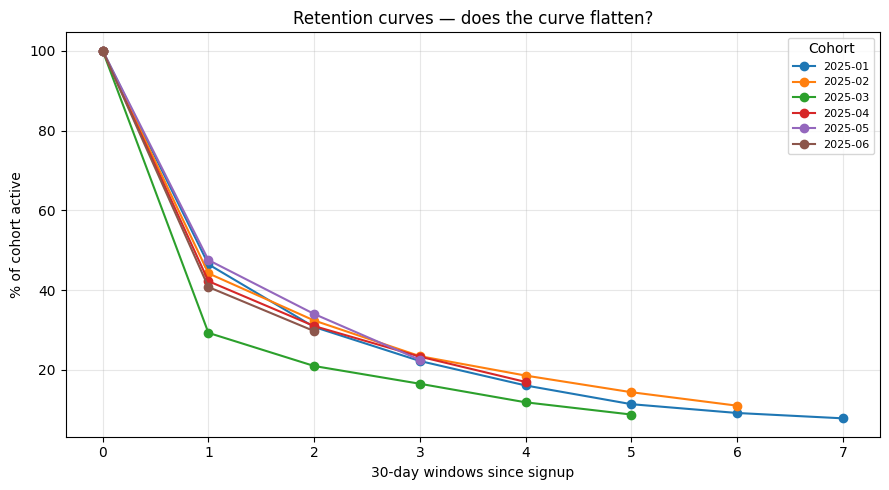

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
for cohort in retention.index:
    row = retention.loc[cohort].dropna()
    ax.plot(row.index, row.values * 100, marker="o", label=str(cohort))
ax.set_xlabel("30-day windows since signup"); ax.set_ylabel("% of cohort active")
ax.set_title("Retention curves — does the curve flatten?")
ax.legend(title="Cohort", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading:** curves are still decaying at M5–M7 rather than flattening — there is
not yet a stable retained core. Combined with the funnel of ~42% M1, the priority is
early-lifecycle retention, not late-stage churn saves.

## 6. Segment by acquisition channel

Averages lie — the blended matrix hides who is actually churning.

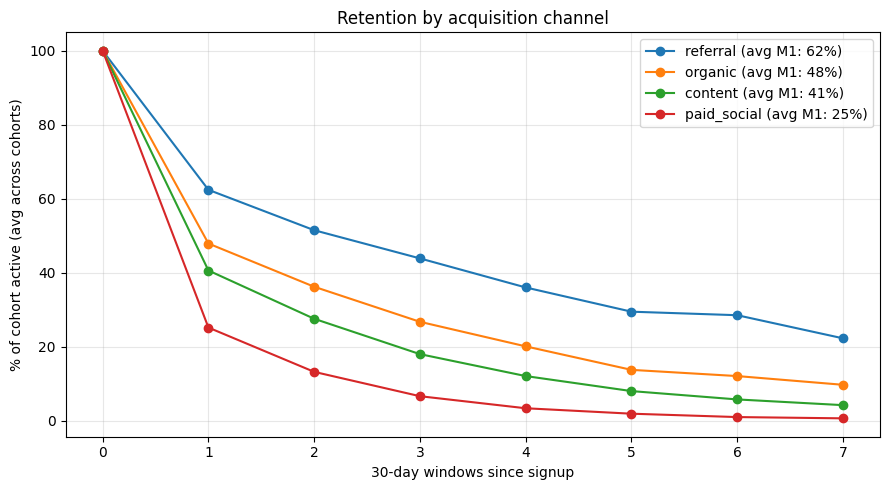

In [24]:
def retention_matrix(frame):
    c = (frame.groupby(["cohort_month", "month_offset"])["user_id"]
         .nunique().unstack(fill_value=0))
    c = mask_immature(c)
    sizes = frame.groupby("cohort_month")["user_id"].nunique()
    return c.div(sizes, axis=0)

channel_m1, channel_curves = {}, {}
for ch, g in value_df.groupby("channel"):
    r = retention_matrix(g)
    channel_curves[ch] = r.mean(axis=0)
    channel_m1[ch] = r[1].mean()

fig, ax = plt.subplots(figsize=(9, 5))
for ch, curve in sorted(channel_curves.items(), key=lambda kv: -kv[1].get(1, 0)):
    curve = curve.dropna()
    ax.plot(curve.index, curve.values * 100, marker="o",
            label=f"{ch} (avg M1: {channel_m1[ch]*100:.0f}%)")
ax.set_xlabel("30-day windows since signup")
ax.set_ylabel("% of cohort active (avg across cohorts)")
ax.set_title("Retention by acquisition channel")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading:** referral users retain at ~2.5x the rate of paid-social users at M1.
Paid social is buying signups, not customers — CAC payback on that channel should be
re-modeled using *retained*-user economics before any budget renewal.

## 7. Behavioral cohort — the activation lever

Compare users who **invited a teammate within 7 days of signup** vs. those who didn't.
⚠️ This is *correlational*: inviters may simply be more committed. It becomes an
activation strategy only after an experiment (e.g., prompting invites in onboarding)
confirms causality.

In [25]:
invites = df[df["event_name"] == "teammate_invited"]
week1_inviters = set(
    invites.loc[(invites["event_date"] - invites["signup_date"]).dt.days <= 7, "user_id"])
value_df["week1_invite"] = value_df["user_id"].isin(week1_inviters)

rows = []
for flag, g in value_df.groupby("week1_invite"):
    r = retention_matrix(g)
    rows.append({"segment": "invited week 1" if flag else "no invite",
                 "users": g["user_id"].nunique(),
                 "avg M1": f"{r[1].mean()*100:.0f}%",
                 "avg M3": f"{r[3].mean()*100:.0f}%"})
pd.DataFrame(rows)

,segment,users,avg M1,avg M3
0,no invite,4079,34%,16%
1,invited week 1,1921,57%,34%


## 8. Opportunity sizing

Translate the finding into money — always with stated, conservative assumptions.

In [26]:
ARPU_MONTHLY = 79          # replace with real ARPU
LIFT = 0.05                 # target: +5pts on M1 retention
HAIRCUT = 0.6               # not all M1-retained users persist; discount the value

avg_m1 = retention[1].mean()
monthly_signups = cohort_sizes.mean()
extra_retained = monthly_signups * LIFT
annual_value = extra_retained * ARPU_MONTHLY * 12 * HAIRCUT

print(f"Avg M1 retention: {avg_m1*100:.0f}%  →  target {avg_m1*100 + 5:.0f}%")
print(f"≈ {extra_retained:.0f} extra retained users per monthly cohort")
print(f"≈ ${annual_value:,.0f} incremental ARR (conservative)")

Avg M1 retention: 42%  →  target 47%
≈ 50 extra retained users per monthly cohort
≈ $28,440 incremental ARR (conservative)


In [51]:
#Bonus Analysis Findings

In [52]:
#Bonus-1: Marketing Channel Quality
user_summary = (
    df.groupby(["user_id", "channel"])
      .agg(total_events=("event_name", "count"))
      .reset_index()
)
channel_summary = (
    user_summary.groupby("channel")
    .agg(users=("user_id", "count"),
         avg_events=("total_events", "mean"))
    .reset_index()
    .sort_values("users", ascending=False)
)
channel_summary["avg_events"] = channel_summary["avg_events"].round(2)

print("Channel quality vs volume")
print(channel_summary.to_string(index=False))   # <-- captured in output

fig = px.scatter(
    channel_summary, x="users", y="avg_events",
    size="users", color="channel", text="channel",
    title="Channel Quality vs Volume",
)
fig.update_layout(template="plotly_white")
fig.show()

Channel quality vs volume
    channel  users  avg_events
    organic   2158        7.35
paid_social   1783        4.86
    content   1211        6.36
   referral    848        9.59


In [53]:
#Bonus-2: User Journey Funnel

steps = ["document_uploaded", "quote_generated", "case_opened",
         "client_message_sent", "teammate_invited"]

funnel_counts = [df[df["event_name"] == step]["user_id"].nunique() for step in steps]

funnel = pd.DataFrame({"step": steps, "users": funnel_counts})
top = funnel["users"].iloc[0]
funnel["pct_of_top"] = (funnel["users"] / top * 100).round(1)

print("User journey funnel (distinct users per event)")
print(funnel.to_string(index=False))            # <-- captured in output

fig = go.Figure(go.Funnel(y=steps, x=funnel_counts))
fig.update_layout(title="User Journey Funnel")
fig.show()

User journey funnel (distinct users per event)
               step  users  pct_of_top
  document_uploaded   4307       100.0
    quote_generated   4265        99.0
        case_opened   4219        98.0
client_message_sent   4247        98.6
   teammate_invited   1921        44.6


In [54]:
#Bonus-3: Power Users
user_activity = (
    df.groupby("user_id").size().reset_index(name="event_count")
)
user_activity["segment"] = pd.cut(
    user_activity["event_count"],
    bins=[0, 5, 15, 50, 1000],
    labels=["Light", "Medium", "Heavy", "Power User"],
)

seg = (user_activity["segment"].value_counts()
       .reindex(["Light", "Medium", "Heavy", "Power User"])
       .rename_axis("segment").reset_index(name="users"))
seg["pct"] = (seg["users"] / seg["users"].sum() * 100).round(1)

print("User segmentation by activity")
print(seg.to_string(index=False))               # <-- captured in output

fig = px.histogram(user_activity, x="segment", title="User Segmentation")
fig.update_layout(template="plotly_white")
fig.show()

User segmentation by activity
   segment  users  pct
     Light   3448 57.5
    Medium   2071 34.5
     Heavy    481  8.0
Power User      0  0.0


In [57]:
#Bonus-4: Time-to-First-Value
value_only = df[df["event_name"].isin(VALUE_EVENTS)]
first_action = (
    value_only.groupby("user_id")
    .agg(signup_date=("signup_date", "first"),
         first_event=("event_date", "min"))
    .reset_index()
)
first_action["days_to_value"] = (
    first_action["first_event"] - first_action["signup_date"]
).dt.days

ttfv = first_action["days_to_value"]
print("Time to first value (days)")
print(f"  users with a value event: {len(ttfv):,}")
print(f"  median: {ttfv.median():.0f} | mean: {ttfv.mean():.1f}")
print(f"  same day (0d): {(ttfv == 0).mean()*100:.1f}%")
print(f"  within 1 day:  {(ttfv <= 1).mean()*100:.1f}%")
print(f"  within 7 days: {(ttfv <= 7).mean()*100:.1f}%")
print(ttfv.describe().round(1).to_string())     # <-- captured in output

fig = px.histogram(first_action, x="days_to_value", nbins=30,
                   title="Days Until First Meaningful Action")
fig.update_layout(template="plotly_white")
fig.show()

Time to first value (days)
  users with a value event: 6,000
  median: 6 | mean: 7.5
  same day (0d): 9.8%
  within 1 day:  18.5%
  within 7 days: 58.7%
count    6000.0
mean        7.5
std         6.5
min         0.0
25%         2.0
50%         6.0
75%        11.0
max        27.0


In [56]:
#Bonus-5: Does Inviting Teammates Increase Retention?

user_events = (
    df.groupby("user_id")["event_name"].apply(list).reset_index()
)
user_events["invited_teammate"] = user_events["event_name"].apply(
    lambda x: "teammate_invited" in x)
user_events["total_events"] = user_events["event_name"].apply(len)

summary = (
    user_events.groupby("invited_teammate")
    .agg(users=("user_id", "count"),
         avg_events=("total_events", "mean"))
    .reset_index()
)
summary["avg_events"] = summary["avg_events"].round(2)

print("Engagement by week-1 invite status")
print(summary.to_string(index=False))           # <-- captured in output

fig = px.bar(summary, x="invited_teammate", y="avg_events",
             text_auto=".2f",
             title="Users Who Invite Teammates Are More Engaged")
fig.update_layout(template="plotly_white")
fig.show()

Engagement by week-1 invite status
 invited_teammate  users  avg_events
            False   4079        5.55
             True   1921        9.23


## 9. Findings & recommendations

| # | Finding | Recommendation |
|---|---|---|
| 1 | **March cohort anomaly**: M1 retention 29% vs ~44% baseline, deficit persists at every age | Audit March onboarding/release changes; ship fix; verify via April+ column read |
| 2 | **Channel quality gap**: referral M1 ≈ 62% vs paid social ≈ 25% | Re-model paid-social CAC on retained users; shift budget toward referral incentives |
| 3 | **Activation lever**: week-1 teammate invite correlates with ~2x M3 retention (34% vs 16%) | Run an A/B test prompting invites during onboarding to test causality |
| 4 | Curves don't flatten by M7 | Early-lifecycle retention is the priority; size: ~$28K ARR per 5pt M1 lift |

## 10. Limitations & next steps

- **Correlation ≠ causation** on the invite finding — experiment required before investment.
- Rolling 30-day windows ≠ calendar months; don't compare these numbers directly to calendar-based benchmarks.
- Cohort sizes (~1,000) make ±3pt differences noisy; the March gap (−15pts) is well outside noise, but treat smaller gaps cautiously.
- Next: rebuild matrices on revenue retention (NRR) rather than user counts; add plan-tier segmentation.
